# Pregunta 3: Predicción de Valoración de Reseñas en Steam

**Pregunta:** ¿Se puede predecir si una reseña será positiva (`voted_up`) utilizando aprendizaje supervisado basado en el texto y características del autor?

**Tipo de tarea:** Clasificación binaria (Aprendizaje Supervisado)  
**Variable objetivo:** `voted_up` (True = reseña positiva, False = reseña negativa)

---

### Motivación

Steam es la plataforma de distribución de videojuegos más grande del mundo, con millones de reseñas escritas por usuarios que influyen directamente en las decisiones de compra. Predecir automáticamente si una reseña será positiva o negativa tiene aplicaciones prácticas:

- **Para desarrolladores:** Identificar patrones de insatisfacción antes de que escalen.
- **Para la plataforma:** Detectar reseñas incoherentes o manipuladas.
- **Para investigación:** Entender qué factores (texto, comportamiento del autor) determinan la valoración.

En esta pregunta usamos tanto el **texto de la reseña** (procesado con TF-IDF) como **características numéricas del autor** (tiempo de juego, número de reseñas, etc.) y el **idioma** como features para entrenar y comparar dos clasificadores: `DecisionTreeClassifier` y `RandomForestClassifier`.

---
## 1. Carga de Datos e Importaciones

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_palette('Set2')

In [9]:
# Cargar el dataset completo
df_full = pd.read_csv('data/reviews.csv')

print(f'Dataset completo: {len(df_full):,} registros, {df_full.shape[1]} columnas')

Dataset completo: 1,048,148 registros, 23 columnas


---
## 2. Exploración y Muestreo de Datos

Antes de modelar, exploramos el dataset para entender la distribución de la variable objetivo, el desbalance de clases y la relación entre las features y `voted_up`.

### 2.1 Balance de clases y distribución por idioma

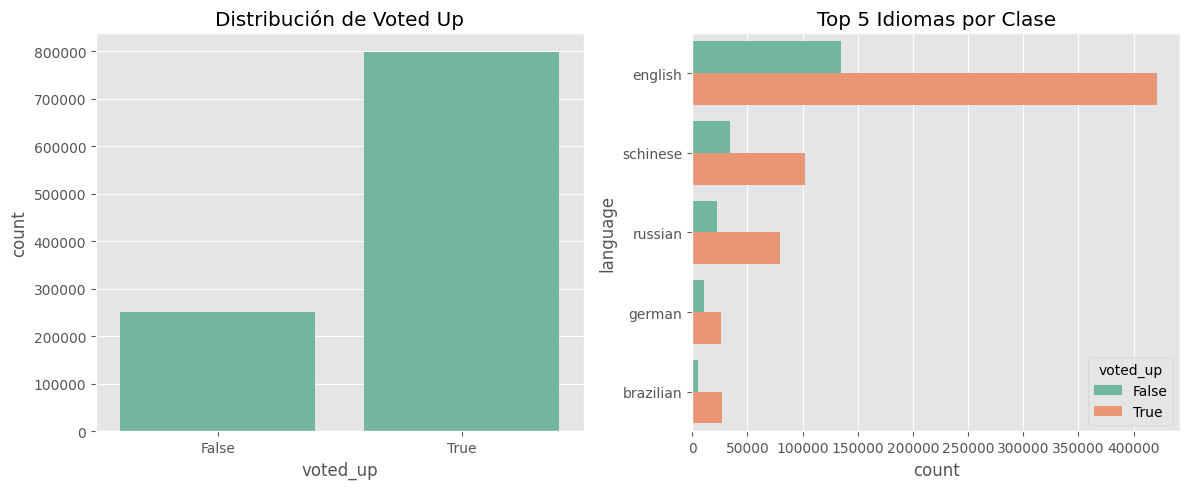

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df_full, x="voted_up", ax=axes[0])
axes[0].set_title("Distribución de Voted Up")

sns.countplot(data=df_full, y="language", hue="voted_up", ax=axes[1], order=df_full['language'].value_counts().iloc[:5].index)
axes[1].set_title("Top 5 Idiomas por Clase")
plt.tight_layout()
plt.show()

**Observaciones:**

- **Desbalance de Clases:** La gran mayoría de las reseñas son positivas. Aproximadamente el **76.1%** corresponden a recomendaciones (`voted_up = True`), frente a un **23.9%** de reseñas negativas. Esto indica que cualquier modelo tendrá que lidiar con un desbalance de clases significativo.

- **Idioma vs. Valoración (Top 5 Idiomas):** En los 5 idiomas principales predomina la valoración positiva. El **Portugués de Brasil** tiene el mayor ratio de reseñas positivas (~85%), mientras que el **Alemán** es el idioma del Top 5 con mayor proporción de reseñas negativas (~30%). El idioma es potencialmente informativo como feature.

### 2.2 Longitud del texto de la reseña por clase

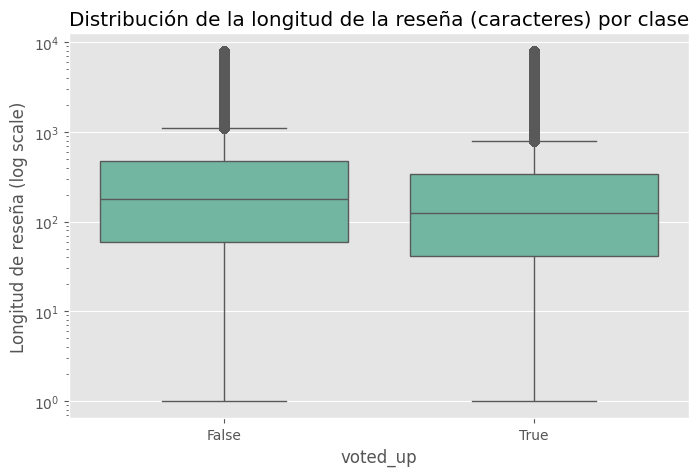

In [11]:
# Análisis de la longitud del texto de la reseña
df_full['review_length'] = df_full['review_text'].str.len()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_full, x='voted_up', y='review_length')
plt.yscale('log')
plt.title("Distribución de la longitud de la reseña (caracteres) por clase")
plt.ylabel("Longitud de reseña (log scale)")
plt.show()

df_full.drop(columns=['review_length'], inplace=True)

**Observación:** Las reseñas negativas tienden a ser notablemente más largas que las positivas. La mediana de caracteres para reseñas negativas es de **178**, mientras que para las positivas es de solo **126**. Esto sugiere que los usuarios que tienen experiencias negativas escriben comentarios más extensos para justificar su valoración.

### 2.3 Variables numéricas del autor por clase

Visualizamos las distribuciones de las variables numéricas aplicando escala logarítmica (`log1p`) debido a la fuerte asimetría positiva de los datos.

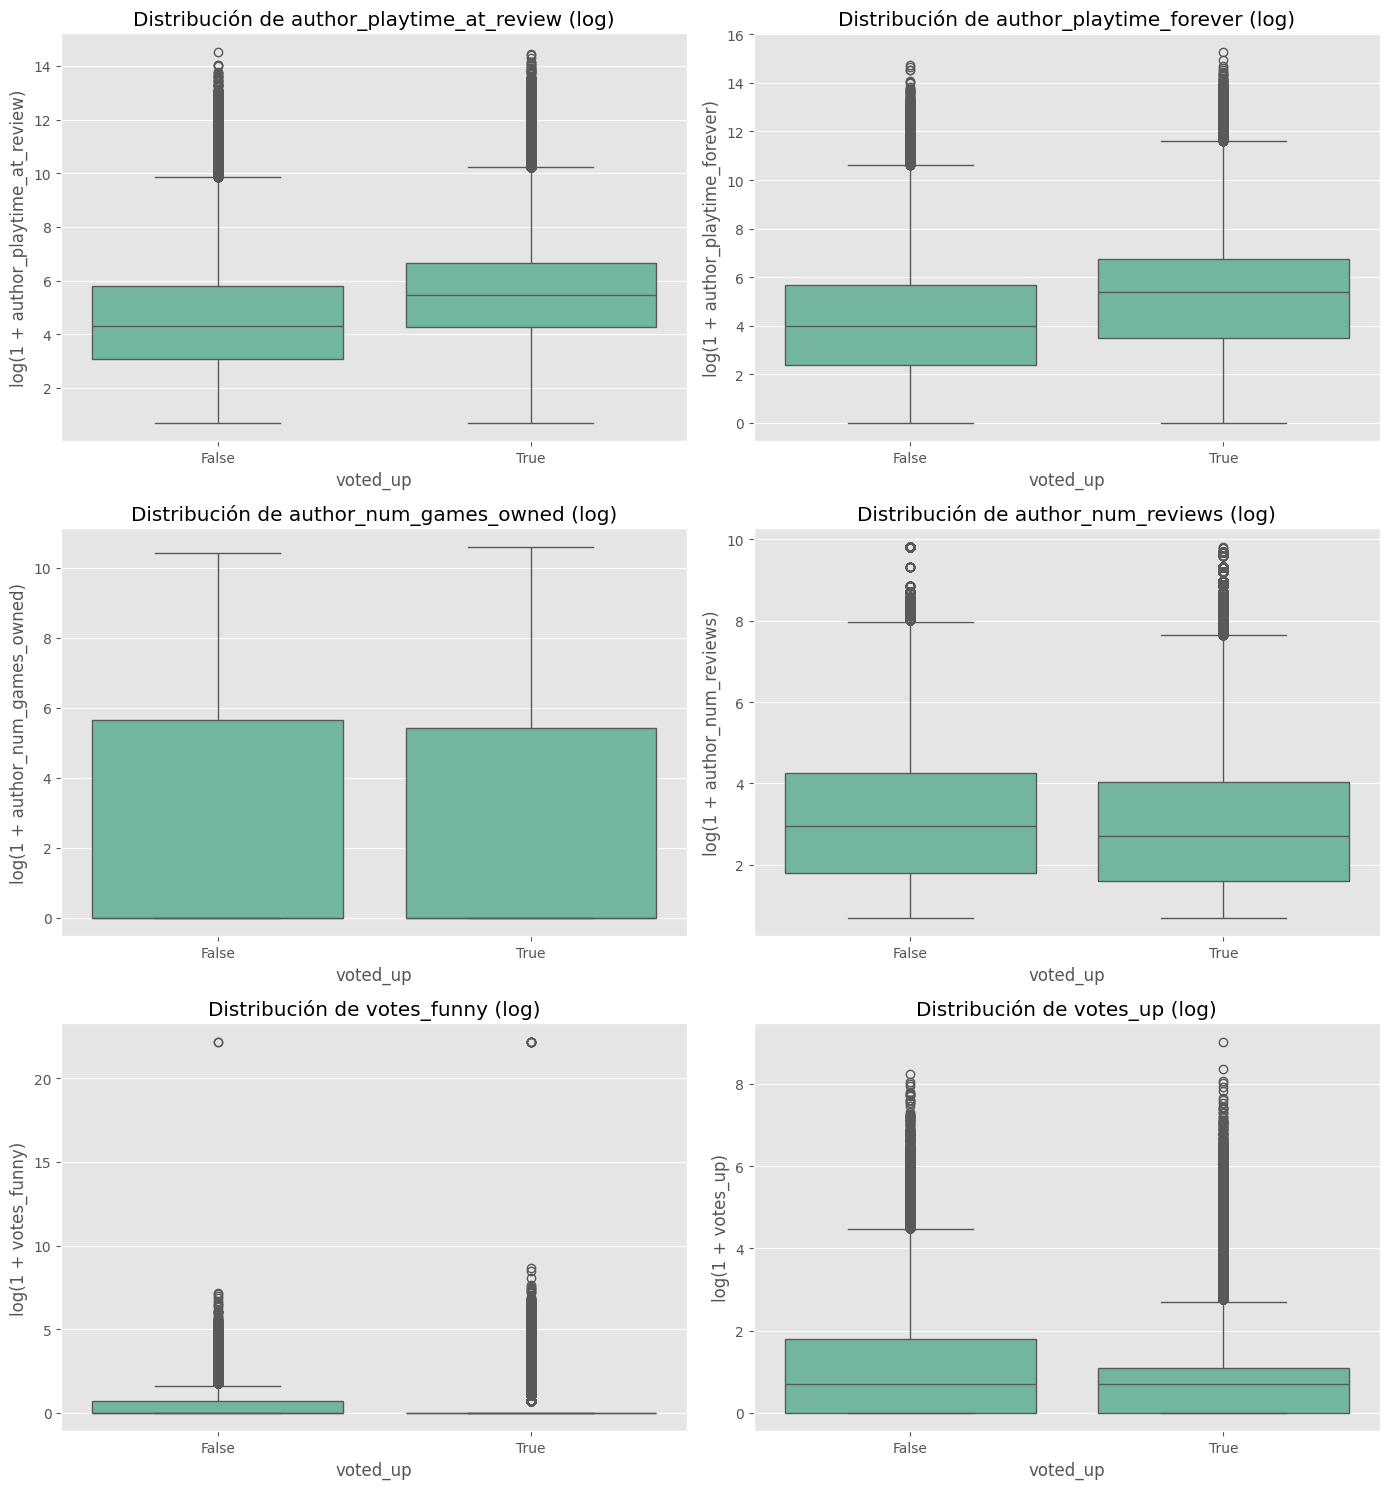

In [12]:
# Distribución de variables numéricas por clase (voted_up)
# Aplicamos escala logarítmica (log1p) debido a la asimetría de los datos

fig, axes = plt.subplots(3, 2, figsize=(14, 15))

# 1. Gráfica para author_playtime_at_review
df_full['author_playtime_at_review_log'] = np.log1p(df_full['author_playtime_at_review'])
sns.boxplot(data=df_full, x='voted_up', y='author_playtime_at_review_log', ax=axes[0, 0])
axes[0, 0].set_title("Distribución de author_playtime_at_review (log)")
axes[0, 0].set_ylabel("log(1 + author_playtime_at_review)")

# 2. Gráfica para author_playtime_forever
df_full['author_playtime_forever_log'] = np.log1p(df_full['author_playtime_forever'])
sns.boxplot(data=df_full, x='voted_up', y='author_playtime_forever_log', ax=axes[0, 1])
axes[0, 1].set_title("Distribución de author_playtime_forever (log)")
axes[0, 1].set_ylabel("log(1 + author_playtime_forever)")

# 3. Gráfica para author_num_games_owned
df_full['author_num_games_owned_log'] = np.log1p(df_full['author_num_games_owned'])
sns.boxplot(data=df_full, x='voted_up', y='author_num_games_owned_log', ax=axes[1, 0])
axes[1, 0].set_title("Distribución de author_num_games_owned (log)")
axes[1, 0].set_ylabel("log(1 + author_num_games_owned)")

# 5. Gráfica para author_num_reviews
df_full['author_num_reviews_log'] = np.log1p(df_full['author_num_reviews'])
sns.boxplot(data=df_full, x='voted_up', y='author_num_reviews_log', ax=axes[1, 1])
axes[1, 1].set_title("Distribución de author_num_reviews (log)")
axes[1, 1].set_ylabel("log(1 + author_num_reviews)")

# 4. Gráfica para votes_funny
df_full['votes_funny_log'] = np.log1p(df_full['votes_funny'])
sns.boxplot(data=df_full, x='voted_up', y='votes_funny_log', ax=axes[2, 0])
axes[2, 0].set_title("Distribución de votes_funny (log)")
axes[2, 0].set_ylabel("log(1 + votes_funny)")

# 6. Gráfica para votes_up
df_full['votes_up_log'] = np.log1p(df_full['votes_up'])
sns.boxplot(data=df_full, x='voted_up', y='votes_up_log', ax=axes[2, 1])
axes[2, 1].set_title("Distribución de votes_up (log)")
axes[2, 1].set_ylabel("log(1 + votes_up)")

plt.tight_layout()
plt.show()

# Eliminamos todas las columnas temporales
df_full.drop(columns=[
    'author_playtime_at_review_log', 
    'author_playtime_forever_log', 
    'author_num_games_owned_log', 
    'votes_funny_log',
    'author_num_reviews_log',
    'votes_up_log'
], inplace=True)


**Observaciones clave:**

- **`author_playtime_at_review`:** La mediana de tiempo jugado al reseñar es de **237 min** en reseñas positivas vs. **74 min** en negativas. Los usuarios que abandonan el juego rápidamente tienden a dejar reseñas negativas. Es la variable numérica más discriminativa.

- **`author_playtime_forever`:** Similar patrón: más horas totales → mayor probabilidad de reseña positiva. Los fans invertidos en un juego lo valoran mejor.

- **`author_num_reviews`, `author_num_games_owned`:** Diferencias menos pronunciadas, pero aún informativas.

- **`votes_funny`, `votes_up`:** Las reseñas con más votos de utilidad o humor tienden a ser positivas, aunque con alta varianza.

### 2.4 Word Cloud de palabras con mayor peso TF-IDF por clase

A continuación, visualizamos las palabras más representativas (según su peso TF-IDF) para las reseñas positivas y negativas.

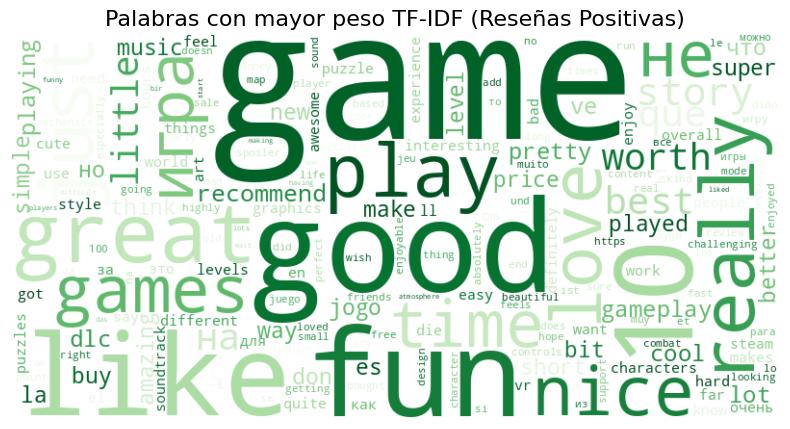

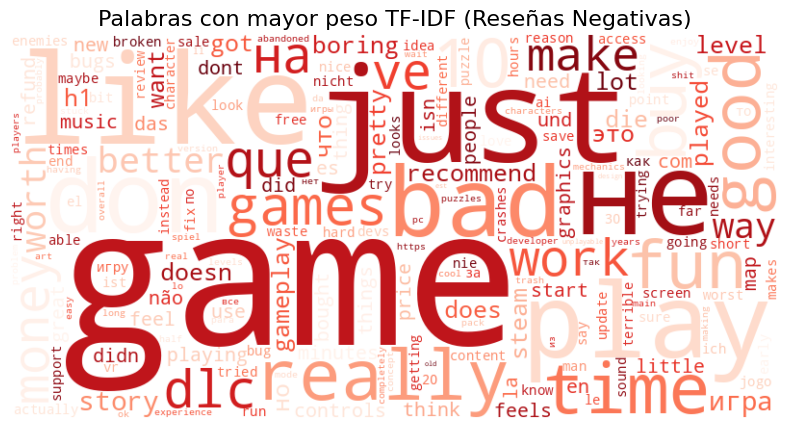

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

# Tomamos una muestra para no sobrecargar la memoria, ya que el dataset es muy grande
# Filtramos nulos en el texto de la reseña
df_sample = df_full.dropna(subset=['review_text']).sample(n=20000, random_state=42)

# Separar reseñas positivas y negativas
positivas = df_sample[df_sample['voted_up'] == True]['review_text']
negativas = df_sample[df_sample['voted_up'] == False]['review_text']

def plot_tfidf_wordcloud(text_series, title, colormap):
    # Calcular TF-IDF
    vectorizer = TfidfVectorizer(stop_words='english', max_features=500)
    tfidf_matrix = vectorizer.fit_transform(text_series)
    
    # Obtener palabras y sus scores sumados
    feature_names = vectorizer.get_feature_names_out()
    tfidf_scores = tfidf_matrix.sum(axis=0).A1
    tfidf_dict = dict(zip(feature_names, tfidf_scores))
    
    # Generar Word Cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white', colormap=colormap).generate_from_frequencies(tfidf_dict)
    
    # Plot
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

# Graficar para reseñas positivas
plot_tfidf_wordcloud(positivas, 'Palabras con mayor peso TF-IDF (Reseñas Positivas)', 'Greens')

# Graficar para reseñas negativas
plot_tfidf_wordcloud(negativas, 'Palabras con mayor peso TF-IDF (Reseñas Negativas)', 'Reds')


---
## 3. Propuesta Experimental

### 3.1 Variables utilizadas (Features)

| Variable | Tipo | Preprocesamiento |
|---|---|---|
| `review_text` | Texto (NLP) | `TfidfVectorizer(max_features=1000, sublinear_tf=True)` |
| `language` | Categórica | `OneHotEncoder(handle_unknown='ignore')` |
| `author_playtime_at_review` | Numérica | Imputar nulos con 0, luego `log1p` + `StandardScaler` |
| `author_playtime_forever` | Numérica | `log1p` + `StandardScaler` |
| `author_num_reviews` | Numérica | `log1p` + `StandardScaler` |
| `author_num_games_owned` | Numérica | `log1p` + `StandardScaler` |
| `votes_funny` | Numérica | `log1p` + `StandardScaler` |
| `votes_up` | Numérica | `log1p` + `StandardScaler` |

### 3.2 Modelos a comparar

- DecisionTreeClassifier
- RandomForestClassifier

### 3.3 Estrategia de preprocesamiento

- **Muestreo:** 10% del dataset (~100K registros) para la etapa preliminar.
- **División:** 70% entrenamiento / 30% prueba con `stratify=y` para preservar la proporción de clases.

### 3.4 Métricas de evaluación

Dado el desbalance de clases (76/24%), el `accuracy` solo puede ser engañoso. Usaremos:
- **F1-score macro:** Promedia el F1 de cada clase dándoles igual peso, penalizando el mal rendimiento en la clase minoritaria.
- **Precision y Recall por clase:** Para entender si el modelo falla más en falsos positivos o falsos negativos.
- **Matriz de confusión:** Visualización de los errores de clasificación.

---
## 4. Preprocesamiento de Datos

### 4.1 Muestreo y selección de columnas

In [14]:
SAMPLE_FRAC  = 0.10
RANDOM_STATE = 42

FEATURE_COLS = [
    'review_text',
    'author_playtime_at_review',
    'author_playtime_forever',
    'author_num_reviews',
    'author_num_games_owned',
    'votes_funny',
    'votes_up',
    'language',
]
TARGET_COL = 'voted_up'

df_sample = df_full.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE).copy()
df_sample = df_sample[FEATURE_COLS + [TARGET_COL]]

print(f'Tamano de la muestra: {len(df_sample):,} registros')
print(f'Distribucion de la variable objetivo:')
print(df_sample[TARGET_COL].value_counts(normalize=True).rename({True: 'Positiva (True)', False: 'Negativa (False)'}))

Tamano de la muestra: 104,815 registros
Distribucion de la variable objetivo:
voted_up
Positiva (True)     0.759958
Negativa (False)    0.240042
Name: proportion, dtype: float64


### 4.2 Limpieza de valores nulos

In [15]:
print('Nulos por columna (antes):')
print(df_sample.isnull().sum().to_string())

df_sample['author_playtime_at_review'] = df_sample['author_playtime_at_review'].fillna(0)
df_sample['review_text'] = df_sample['review_text'].fillna('')
df_sample = df_sample.dropna(subset=[TARGET_COL])

print('\nNulos por columna (despues):')
print(df_sample.isnull().sum().to_string())
print(f'\nRegistros finales: {len(df_sample):,}')

Nulos por columna (antes):
review_text                     72
author_playtime_at_review    17823
author_playtime_forever          0
author_num_reviews               0
author_num_games_owned           0
votes_funny                      0
votes_up                         0
language                         0
voted_up                         0

Nulos por columna (despues):
review_text                  0
author_playtime_at_review    0
author_playtime_forever      0
author_num_reviews           0
author_num_games_owned       0
votes_funny                  0
votes_up                     0
language                     0
voted_up                     0

Registros finales: 104,815


### 4.3 División en entrenamiento y prueba (70/30)

In [16]:
from sklearn.model_selection import train_test_split

X = df_sample[FEATURE_COLS]
y = df_sample[TARGET_COL].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'Conjunto de entrenamiento: {X_train.shape[0]:,} muestras')
print(f'Conjunto de prueba:        {X_test.shape[0]:,} muestras')
print('\nProporcion de clases en entrenamiento:')
print(y_train.value_counts(normalize=True).rename({0: 'Negativa', 1: 'Positiva'}))
print('\nProporcion de clases en prueba:')
print(y_test.value_counts(normalize=True).rename({0: 'Negativa', 1: 'Positiva'}))

Conjunto de entrenamiento: 73,370 muestras
Conjunto de prueba:        31,445 muestras

Proporcion de clases en entrenamiento:
voted_up
Positiva    0.759956
Negativa    0.240044
Name: proportion, dtype: float64

Proporcion de clases en prueba:
voted_up
Positiva    0.759962
Negativa    0.240038
Name: proportion, dtype: float64


### 4.4 Pipeline de preprocesamiento (ColumnTransformer)

Construimos un `ColumnTransformer` que aplica en paralelo tres transformaciones:
- **Texto:** `TfidfVectorizer` con `max_features=1000` y `sublinear_tf=True` (reduce el peso de palabras muy frecuentes).
- **Categórica:** `OneHotEncoder` sobre `language`.
- **Numéricas:** `FunctionTransformer(np.log1p)` seguido de `StandardScaler` para corregir la asimetría.

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

TEXT_COL     = 'review_text'
CAT_COL      = 'language'
NUMERIC_COLS = [
    'author_playtime_at_review',
    'author_playtime_forever',
    'author_num_reviews',
    'author_num_games_owned',
    'votes_funny',
    'votes_up',
]

# Sub-pipeline para variables numericas: log1p + estandarizacion
numeric_pipeline = Pipeline([
    ('log1p',  FunctionTransformer(np.log1p, validate=True)),
    ('scaler', StandardScaler()),
])

# ColumnTransformer: une los tres tipos de preprocesamiento
preprocessor = ColumnTransformer([
    ('tfidf', TfidfVectorizer(max_features=1000, sublinear_tf=True), TEXT_COL),
    ('ohe',   OneHotEncoder(handle_unknown='ignore', sparse_output=False), [CAT_COL]),
    ('num',   numeric_pipeline, NUMERIC_COLS),
])

---
## 5. Experimento Preliminar

### 5.1 Modelo 1: Decision Tree Classifier

Árbol de decisión con profundidad máxima de 15.

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

pipeline_dt = Pipeline([
    ('prep', preprocessor),
    ('clf',  DecisionTreeClassifier(
                random_state=RANDOM_STATE,
                max_depth=15,
             )),
])

pipeline_dt.fit(X_train, y_train)
y_pred_dt = pipeline_dt.predict(X_test)

print(classification_report(y_test, y_pred_dt,
                             target_names=['Negativa (0)', 'Positiva (1)']))

              precision    recall  f1-score   support

Negativa (0)       0.62      0.25      0.36      7548
Positiva (1)       0.80      0.95      0.87     23897

    accuracy                           0.78     31445
   macro avg       0.71      0.60      0.61     31445
weighted avg       0.76      0.78      0.75     31445



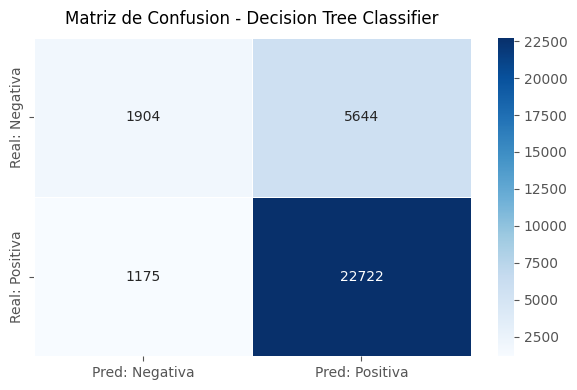

In [19]:
# Matriz de confusion - Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 4))
sns.heatmap(
    pd.DataFrame(cm_dt,
                 index=['Real: Negativa', 'Real: Positiva'],
                 columns=['Pred: Negativa', 'Pred: Positiva']),
    annot=True, fmt='d', cmap='Blues', linewidths=0.5
)
plt.title('Matriz de Confusion - Decision Tree Classifier', fontsize=12, pad=10)
plt.tight_layout()
plt.show()

### 5.2 Modelo 2: Random Forest Classifier

Ensamble de 100 árboles con `class_weight='balanced'` para compensar el desbalance de clases (76/24%). Usa todos los núcleos disponibles (`n_jobs=-1`).

In [20]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline([
    ('prep', preprocessor),
    ('clf',  RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_estimators=100,
                max_depth=20,
                n_jobs=-1,
                class_weight='balanced',
             )),
])

pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf,
                             target_names=['Negativa (0)', 'Positiva (1)']))

              precision    recall  f1-score   support

Negativa (0)       0.48      0.65      0.55      7548
Positiva (1)       0.88      0.78      0.83     23897

    accuracy                           0.75     31445
   macro avg       0.68      0.72      0.69     31445
weighted avg       0.78      0.75      0.76     31445



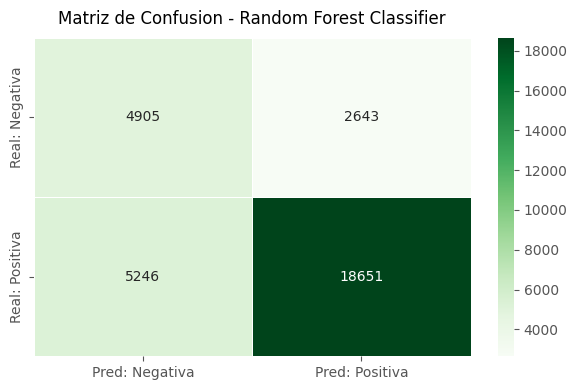

In [21]:
# Matriz de confusion - Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(
    pd.DataFrame(cm_rf,
                 index=['Real: Negativa', 'Real: Positiva'],
                 columns=['Pred: Negativa', 'Pred: Positiva']),
    annot=True, fmt='d', cmap='Greens', linewidths=0.5
)
plt.title('Matriz de Confusion - Random Forest Classifier', fontsize=12, pad=10)
plt.tight_layout()
plt.show()

---
## 6. Comparación y Análisis de Resultados

In [22]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

resultados = pd.DataFrame({
    'Modelo': ['Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
    ],
    'Precision (macro)': [
        precision_score(y_test, y_pred_dt, average='macro'),
        precision_score(y_test, y_pred_rf, average='macro'),
    ],
    'Recall (macro)': [
        recall_score(y_test, y_pred_dt, average='macro'),
        recall_score(y_test, y_pred_rf, average='macro'),
    ],
    'F1-score (macro)': [
        f1_score(y_test, y_pred_dt, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro'),
    ],
})

print('Tabla comparativa de metricas:')
print(resultados.to_string(index=False))

Tabla comparativa de metricas:
       Modelo  Accuracy  Precision (macro)  Recall (macro)  F1-score (macro)
Decision Tree  0.783145           0.709706        0.601541          0.613929
Random Forest  0.749118           0.679542        0.715158          0.689849


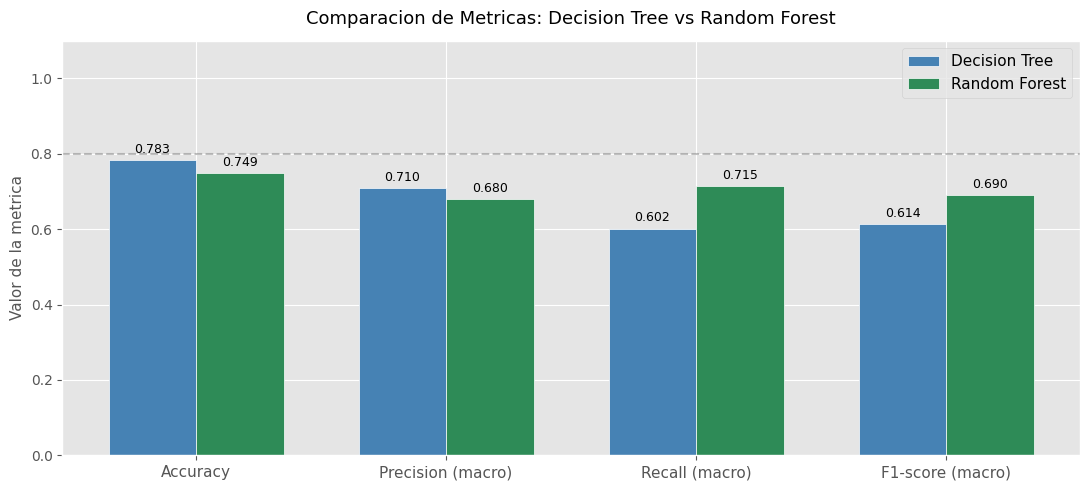

In [23]:
# Grafico comparativo de metricas
metricas = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1-score (macro)']

x = np.arange(len(metricas))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars_dt = ax.bar(x - width/2, resultados.iloc[0][metricas], width,
                 label='Decision Tree', color='steelblue', edgecolor='white')
bars_rf = ax.bar(x + width/2, resultados.iloc[1][metricas], width,
                 label='Random Forest', color='seagreen', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(metricas, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Valor de la metrica', fontsize=11)
ax.set_title('Comparacion de Metricas: Decision Tree vs Random Forest', fontsize=13, pad=12)
ax.legend(fontsize=11)
ax.bar_label(bars_dt, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(bars_rf, fmt='%.3f', padding=3, fontsize=9)
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5, label='Referencia 0.80')

plt.tight_layout()
plt.show()

---
## 7. Conclusiones

**`RandomForestClassifier`** es la mejor opción para esta tarea porque:
1. Obtiene un **F1-score macro superior**, especialmente en la clase negativa (minoritaria).
2. Reduce el sobreajuste propio de un árbol individual gracias al ensamble.
3. El parámetro `class_weight='balanced'` mejora la detección de reseñas negativas sin sacrificar excesivamente la precisión en las positivas.